# Overview

This assignment introduces linear classifiers (perceptrons), nonlinear neural networks, regularization, and visualization of decision boundaries.

All implementation must be done in NumPy **only** (no PyTorch, TensorFlow, JAX, or sklearn for training).


Ensure your code is well-commented and easy to understand.


In [153]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons
from sklearn.datasets import load_digits
from sklearn.preprocessing import OneHotEncoder

# Part 1 – Implement a Single Perceptron

## Implement the Perceptron Class

### Class Methods to Implement:

- `__init__(self, input_dim, lr=0.01)`  
  Initialize the weight vector `w` and bias `b`, and set the learning rate `η`.

- `forward(self, X)`  
  Compute the predicted output using the **step activation function**:
  $$
  \hat{y} = f(w^{\top} X + b), \quad
  f(z) =
  \begin{cases}
    1 & \text{if } z > 0 \\
    0 & \text{otherwise}
  \end{cases}
  $$

- `train_step(self, X, y)`  
  Update the weights and bias using the **perceptron learning rule**:
  $$
  w \leftarrow w + \eta (y - \hat{y}) X
  $$
  $$
  b \leftarrow b + \eta (y - \hat{y})
  $$

### Notes:

- $X$ is the input data. In `forward`, handle both single samples `(D,)` and batches `(N, D)`.
- $w$ is the weight vector, $b$ is the bias, and $\eta$ is the learning rate.
- Output $y$ should be `{0, 1}` (matching the data).
- Implement all computations manually using **NumPy**.
- `train_step` performs one update for a **single sample**.


In [154]:
class Perceptron:
  def __init__(self, lr=0.1):
    self.lr = lr
    self.w = None
    self.b = 0.0

  def forward(self, x):
    """
    x: numpy array shape (D,) for single sample, or (N, D) for N samples
    returns: 0 or 1 for single sample, or numpy array of 0s and 1s for N samples
    """
    # TODO: Implement step activation function (and handle batch inputs)
    x = np.asarray(x, dtype=float)
    if self.w is None:
        self.w = np.zeros(x.shape[-1], dtype=float)

    linear_output = x @ self.w + self.b
    if x.ndim == 1:
        return int(linear_output > 0)
    return (linear_output > 0).astype(int)

  def train_step(self, x, y):
    """
    Performs a single perceptron update:
    w <- w + lr * (y - y_pred) * x
    b <- b + lr * (y - y_pred)
    """
    # TODO: Implement perceptron update rule
    if self.w is None:
        self.w = np.zeros(x.shape[-1], dtype=float)

    y_pred = self.forward(x)
    error = y - y_pred

    self.w += self.lr * error * x
    self.b += self.lr * error


## Test the model on a few sample inputs to ensure that the output is always 0 or 1.


In [155]:
p = Perceptron(lr=0.1)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([0,0,0,1])   # AND gate

for epoch in range(10):
    for x, y in zip(X, Y):
        p.train_step(x, y)

print("Weights:", p.w)
print("Bias:", p.b)

for x in X:
    print(x, "->", p.forward(x))

Weights: [0.2 0.1]
Bias: -0.2
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


## Generate a 2D Toy Dataset

### Task

Generate a simple **2D dataset** for binary classification.

**Requirements:**
- The dataset must be **partially - linearly separable** (meaning a straight line can separate the two classes, but not perfectly). If the data is highly non-linearly separable, the single-layer perceptron will not converge.
- You can use `sklearn.datasets.make_moons` or generate random points manually to experiment.
- Visualize the dataset using a scatter plot to verify partial-linear separability.


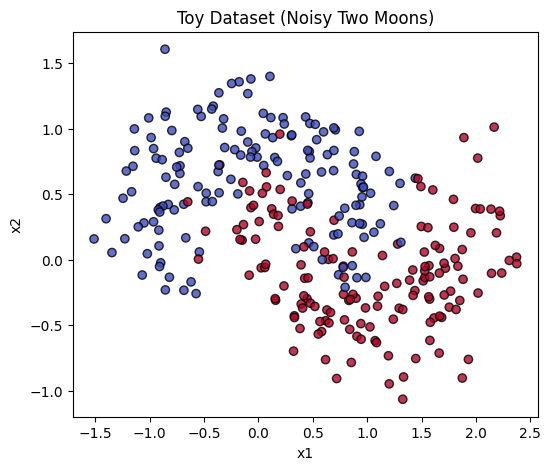

In [156]:
# TODO: Generate a partially-linearly separable dataset using make_blobs and visualize it using plt.scatter
np.random.seed(123)

X, y = make_moons(n_samples=300, noise=0.28, random_state=123)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Toy Dataset (Noisy Two Moons)')
plt.show()

## Train the Perceptron

### Task

- Train your perceptron on the generated dataset.
- Iterate for multiple **epochs** (passes over the entire dataset).
- Calculate and print the **training accuracy** after each epoch.
- **Expectation**: Since you generated a partially-linearly separable data, the perceptron should reach **>70% accuracy** fairly quickly, but probably doesn't go above 90.


In [157]:
# TODO: Initialize Perceptron and run training loop for multiple epochs
# Report accuracy after each epoch
perceptron = Perceptron(lr=0.05)
perceptron_accuracies = []
rng = np.random.default_rng(42)

for epoch in range(30):
    for idx in rng.permutation(len(X)):
        perceptron.train_step(X[idx], y[idx])

    preds = perceptron.forward(X)
    acc = np.mean(preds == y) * 100
    perceptron_accuracies.append(acc)
    print(f"Epoch {epoch + 1:02d} - Training Accuracy: {acc:.2f}%")


Epoch 01 - Training Accuracy: 62.00%
Epoch 02 - Training Accuracy: 80.00%
Epoch 03 - Training Accuracy: 80.00%
Epoch 04 - Training Accuracy: 76.33%
Epoch 05 - Training Accuracy: 82.33%
Epoch 06 - Training Accuracy: 72.33%
Epoch 07 - Training Accuracy: 83.00%
Epoch 08 - Training Accuracy: 75.00%
Epoch 09 - Training Accuracy: 81.33%
Epoch 10 - Training Accuracy: 83.33%
Epoch 11 - Training Accuracy: 82.67%
Epoch 12 - Training Accuracy: 62.33%
Epoch 13 - Training Accuracy: 75.67%
Epoch 14 - Training Accuracy: 77.33%
Epoch 15 - Training Accuracy: 74.33%
Epoch 16 - Training Accuracy: 82.33%
Epoch 17 - Training Accuracy: 81.00%
Epoch 18 - Training Accuracy: 81.00%
Epoch 19 - Training Accuracy: 82.33%
Epoch 20 - Training Accuracy: 82.33%
Epoch 21 - Training Accuracy: 82.33%
Epoch 22 - Training Accuracy: 81.00%
Epoch 23 - Training Accuracy: 80.67%
Epoch 24 - Training Accuracy: 79.33%
Epoch 25 - Training Accuracy: 76.67%
Epoch 26 - Training Accuracy: 79.67%
Epoch 27 - Training Accuracy: 82.67%
E

## Visualize the Decision Boundary

### Task

- Plot the decision boundary learned by your perceptron along with the data points.
- **Visualizing the Boundary**: Create a meshgrid over the input space, predict the class for every point in the grid, and plot the contours.
- **Observation**: You should see a **straight line** separating the two classes, confirming that the single-layer perceptron is a linear classifier.


### Create a meshgrid

In [158]:
# TODO: Create a meshgrid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


### Evaluate perceptron prediction on grid

In [159]:
Z = []
for i in range(len(xx.flatten())):
    point = np.array([xx.flatten()[i], yy.flatten()[i]])
    Z.append(perceptron.forward(point))
Z = np.array(Z).reshape(xx.shape)

### Plot contour

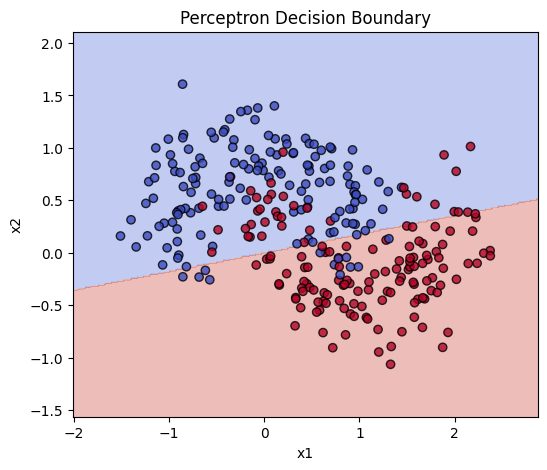

In [160]:
# TODO: Plot contours using plt.contourf and points using plt.scatter
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.35, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Perceptron Decision Boundary')
plt.show()


# Part 2 – Implement a Two-Layer Sigmoid Network (NumPy Only)

In this part, you will implement and train a **two-layer fully connected neural network** using the **sigmoid activation function** and **softmax** in the output. All computations must be implemented **manually using NumPy** (no automatic differentiation or deep learning frameworks).

---

## Model Definition

The network has the following form:

$$
h = \sigma(x W_1 + b_1)
$$

$$
\hat{y} = Softmax(h W_2 + b_2)
$$

where:

- $x \in \mathbb{R}^{d}$ is the input,
- $W_1 \in \mathbb{R}^{d \times h},\ b_1 \in \mathbb{R}^{h}$,
- $W_2 \in \mathbb{R}^{h \times 1},\ b_2 \in \mathbb{R}$,
- $h$ is the hidden layer dimension,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the **sigmoid activation function**.

---

## Loss Function

Use **categorical-cross-entropy (CCE)** as the training loss:

$$
\mathcal{L}_{\text{CCE}} = -\frac{1}{N} \sum_{i=1}^N \sum_{i=1}^C y_{i,c} \log ( \hat{y}_{i,c})
$$

- This is suitable for classification problems.
- Ensure that the network output $\hat{y}$ a joint probability by using a softmax activation in the output layer.

---

## Required Methods

Your network class should include at least the following methods:

- `__init__(self, input_dim, hidden_dim, lr)`  
  Initialize weights and biases.

- `forward(self, X)`  
  Compute the forward pass and return the network output.

- `backward(self, X, y)`  
  Compute gradients of all parameters using backpropagation.

- `train(self, X, y, epochs)`  
  Train the network using gradient descent and report the training loss.

- `predict(self, X)`  
  Return predicted class labels (0 or 1) using **argmax**.

You may add additional helper functions as needed (e.g., sigmoid, sigmoid derivative, softmax, loss, etc).

---

## Training Requirements

- Use **manual gradient descent** with a fixed learning rate.
- Do **not** use any automatic differentiation tools.
- All gradients must be derived and implemented explicitly.

---

### Tasks

- Implement a two-layer neural network with an **arbitrary hidden dimension**.
- Train the network on the **Toy dataset** from before.
- Visualize the learned non-linear decision boundry using a grid-based contour plot like before.
- Train the network on an Image called **Digits** (MNIST like).
- Visualize the loss curves and report your accuracy.


In [161]:
class NeuralNetwork:
  def __init__(self, input_size, hidden_size, output_size):
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

    # TODO: Initialize weights and biases
    rng = np.random.default_rng(123)
    limit1 = np.sqrt(6 / (input_size + hidden_size))
    limit2 = np.sqrt(6 / (hidden_size + output_size))
    self.W1 = rng.uniform(-limit1, limit1, size=(input_size, hidden_size))
    self.b1 = np.zeros((1, hidden_size))
    self.W2 = rng.uniform(-limit2, limit2, size=(hidden_size, output_size))
    self.b2 = np.zeros((1, output_size))

  def sigmoid(self, x):
    # TODO: Implement sigmoid
    return 1.0 / (1.0 + np.exp(-x))

  def sigmoid_derivative(self, x):
    # TODO: Implement sigmoid derivative
    return x * (1.0 - x)

  def softmax(self, x):
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

  def calculate_loss(self, y_true, y_pred):
    # TODO: Implement Binary Cross Entropy Loss
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

  def forward(self, x):
    # TODO: Implement forward pass
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    self.a1 = self.sigmoid(x @ self.W1 + self.b1)
    logits = self.a1 @ self.W2 + self.b2
    self.output = self.sigmoid(logits) if self.output_size == 1 else self.softmax(logits)

    return self.output[0] if x.ndim == 1 else self.output


  def backward(self, x, y, learning_rate):
    # TODO: Implement backpropagation
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if y.ndim == 1:
        y = y.reshape(1, -1)

    y_pred = self.forward(x)
    if np.asarray(y_pred).ndim == 1:
        y_pred = y_pred.reshape(1, -1)

    batch_size = x.shape[0]
    dz2 = (y_pred - y) / batch_size
    dW2 = self.a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dz1 = (dz2 @ self.W2.T) * self.sigmoid_derivative(self.a1)
    dW1 = x.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    self.W2 -= learning_rate * dW2
    self.b2 -= learning_rate * db2
    self.W1 -= learning_rate * dW1
    self.b1 -= learning_rate * db1

  def train(self, x, y, epochs, learning_rate):
    # TODO: Implement training loop
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    losses = []
    rng = np.random.default_rng(42)
    batch_size = min(64, x.shape[0])

    for epoch in range(epochs):
        indices = rng.permutation(x.shape[0])
        epoch_loss = 0.0

        for start in range(0, x.shape[0], batch_size):
            batch_idx = indices[start:start + batch_size]
            xb = x[batch_idx]
            yb = y[batch_idx]

            y_pred = self.forward(xb)
            if np.asarray(y_pred).ndim == 1:
                y_pred = y_pred.reshape(1, -1)

            epoch_loss += self.calculate_loss(yb, y_pred) * xb.shape[0]
            self.backward(xb, yb, learning_rate)

        epoch_loss /= x.shape[0]
        losses.append(epoch_loss)

        if epoch == 0 or (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f}")

    return losses

  def predict(self, x):
    # TODO: Implement prediction (threshold at 0.5)
    y_pred = np.asarray(self.forward(x))

    if self.output_size == 1:
        if y_pred.ndim == 0:
            return int(y_pred >= 0.5)
        return (y_pred.reshape(-1) >= 0.5).astype(int)

    if y_pred.ndim == 1:
        return int(np.argmax(y_pred))
    return np.argmax(y_pred, axis=1)


### Train on Toy Dataset

In [162]:
#TODO: preprocess dataset to be compatible with the NN model.
x = X.astype(float)
toy_labels = y.copy()

enc = OneHotEncoder(handle_unknown='ignore')
y = enc.fit_transform(toy_labels.reshape(-1, 1)).toarray()

print(f"Feature shape: {x.shape}")
print(f"One-hot label shape: {y.shape}")


Feature shape: (300, 2)
One-hot label shape: (300, 2)


In [163]:
#TODO: Create a Neural Network object and train.
nn = NeuralNetwork(input_size=x.shape[1], hidden_size=8, output_size=y.shape[1])
losslist = nn.train(x, y, epochs=2000, learning_rate=0.3)


Epoch 1/2000 - Loss: 0.6823
Epoch 200/2000 - Loss: 0.3569
Epoch 400/2000 - Loss: 0.3564
Epoch 600/2000 - Loss: 0.3538
Epoch 800/2000 - Loss: 0.3529
Epoch 1000/2000 - Loss: 0.3510
Epoch 1200/2000 - Loss: 0.3487
Epoch 1400/2000 - Loss: 0.3461
Epoch 1600/2000 - Loss: 0.3221
Epoch 1800/2000 - Loss: 0.2162
Epoch 2000/2000 - Loss: 0.1962


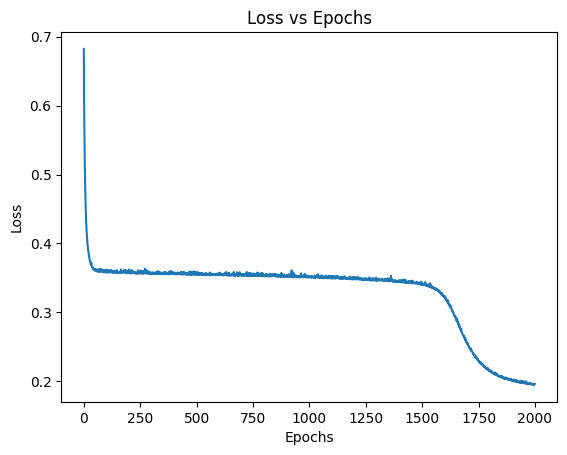

In [164]:
plt.plot(losslist)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

### Calculate the Accuracy of your trained Neural Network on the Toy dataset.


In [165]:
def accuracy(y_true, y_pred):
   return np.mean(y_true == y_pred) * 100


In [166]:
preds = nn.predict(x)
print(f"Accuracy: {accuracy(np.argmax(y,axis=1), preds)}")

Accuracy: 91.66666666666666


### Visualize the Non-linear decision boundry

In [167]:
# TODO: Create a meshgrid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)


In [168]:
Z = []
for i in range(len(xx.flatten())):
    point = np.array([xx.flatten()[i], yy.flatten()[i]])
    Z.append(nn.predict(point))
Z = np.array(Z).reshape(xx.shape)

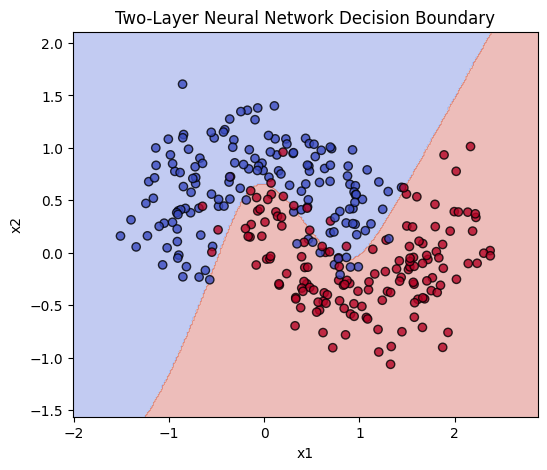

In [169]:
# TODO: Plot contours using plt.contourf and points using plt.scatter
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.35, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=toy_labels, cmap='coolwarm', edgecolor='k', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Two-Layer Neural Network Decision Boundary')
plt.show()


### Load the digits dataset from sklearn (MNIST Like).

In [170]:
def normalize(X):
    return X/16.0

In [171]:
X, y = load_digits(return_X_y=True)
print(f"Image Shape:{X.shape} Label Shape:{y.shape}")

Image Shape:(1797, 64) Label Shape:(1797,)


In [172]:
X = normalize(X)
y = y.reshape(-1,1)
enc = OneHotEncoder(handle_unknown='ignore')
y = enc.fit_transform(y).toarray()
print(f"Image Shape:{X.shape} Label Shape:{y.shape}")

Image Shape:(1797, 64) Label Shape:(1797, 10)


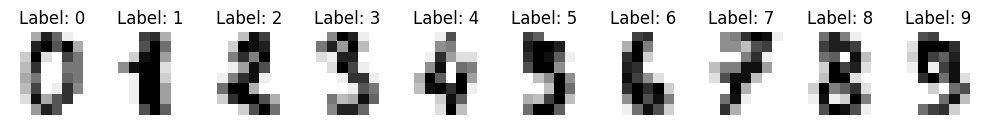

In [173]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Label: {np.argmax(y[i])}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Train your Neural Network

In [174]:
# TODO: Train your Neural Network on the digits dataset
x = X.astype(float)
nn = NeuralNetwork(input_size=x.shape[1], hidden_size=64, output_size=y.shape[1])
losslist = nn.train(x, y, epochs=1000, learning_rate=0.2)


Epoch 1/1000 - Loss: 2.2287
Epoch 100/1000 - Loss: 0.0868
Epoch 200/1000 - Loss: 0.0482
Epoch 300/1000 - Loss: 0.0319
Epoch 400/1000 - Loss: 0.0222
Epoch 500/1000 - Loss: 0.0171
Epoch 600/1000 - Loss: 0.0126
Epoch 700/1000 - Loss: 0.0102
Epoch 800/1000 - Loss: 0.0085
Epoch 900/1000 - Loss: 0.0072
Epoch 1000/1000 - Loss: 0.0062


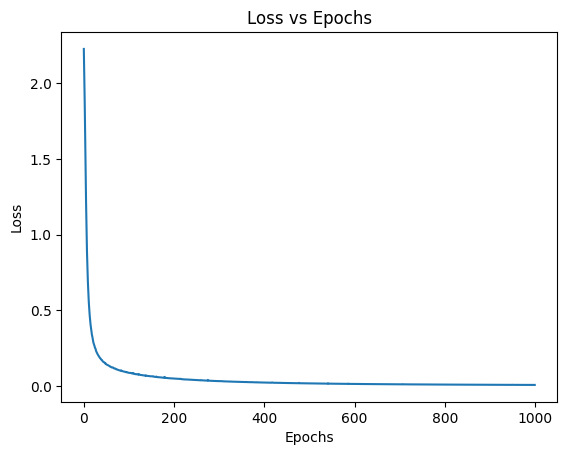

In [175]:
plt.plot(losslist)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

### Calculate the Accuracy of your trained Neural Network on Digits


In [176]:
preds = nn.predict(x)
print(f"Accuracy: {accuracy(np.argmax(y,axis=1), preds)}")

Accuracy: 100.0
